# WEEK 2 AI Foundations (LLMs, Transformers, BERT, GPT)

This notebook is designed for **session recording**: concept + quick code demos.

## Agenda
1. What is a Language Model
2. Tokens, Tokenization, Vocabulary
3. Embeddings & Vector Space Intuition
4. Transformer Architecture
5. Attention Mechanism
6. Encoder vs Decoder vs Seq2Seq
7. BERT Explained
8. GPT Model Family
9. How LLMs Reason
10. Limitations of LLMs

## 0) Environment Setup

In [2]:
# Student Tip: Use this cell only if required packages are missing.
# Add a pip install command for: transformers, sentence-transformers, scikit-learn, matplotlib, seaborn, torch.
# Run once, then restart/re-run imports if needed.
# %pip install -q transformers sentence-transformers scikit-learn matplotlib seaborn torch

In [3]:
# Student Tip: Import all libraries used in this notebook and set a random seed.
# Include numpy, matplotlib, sklearn utilities, transformers, and SentenceTransformer.
# Confirm imports run without errors before moving ahead.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

np.random.seed(42)

d:\Mentoring\learwithsarvesh\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1) What is a Language Model
A language model estimates probability of the next token: 

$P(w_t | w_1, w_2, ..., w_{t-1})$

In practice, modern LLMs generate text token-by-token based on this objective.

In [4]:
# Student Tip: Create a small next-word probability dictionary for language model intuition.
# Sort by probability in descending order and print the ranked output.
# Observe how the highest-probability token is selected first.

next_word_probs = {
    "machine": 0.35,
    "deep": 0.25,
    "neural": 0.20,
    "data": 0.15,
    "random": 0.05
}

# Sort words from highest to lowest probability and display the ranking.
sorted(next_word_probs.items(), key=lambda x: x[1], reverse=True)

[('machine', 0.35),
 ('deep', 0.25),
 ('neural', 0.2),
 ('data', 0.15),
 ('random', 0.05)]

### LM Context from Slides
- **Where we see LMs:** search, chatbots, autocomplete, summarization, code assistants.
- **Evolution:** n-gram models â†’ RNN/LSTM â†’ Transformers â†’ modern LLMs.
- **What they learn from:** books, websites, articles, code, conversations.
- **How they work:** convert text to tokens, predict next token probabilities, and generate token-by-token.

## 2) Tokens, Tokenization, Vocabulary (Coding Demo)

### Quick Difference: Token vs Tokenization vs Vocabulary
- **Token:** one unit the model reads (word, subword, punctuation, or symbol).
- **Tokenization:** the process that splits text into tokens.
- **Vocabulary:** the fixed list of tokens a model knows.

Example:
- Text: `unbelievable!`
- Tokenization (BERT) might produce: `['un', '##bel', '##ie', '##vable', '!']`
- Each token maps to an ID from the model vocabulary.

In [5]:
# Student Tip: Load a BERT tokenizer and tokenize one sample sentence.
# Print original text, tokens, token IDs, and vocabulary size.
# Focus on how text becomes model-readable units.
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

text = "Transformers are changing how we build AI products in 2026!"

tokens = tokenizer.tokenize(text)

token_ids = tokenizer.convert_tokens_to_ids(tokens)

# Show original sentence for reference.
print("Original text:", text)

# Show tokenized output.
print("Tokens:", tokens)

# Show numeric IDs used by the model.
print("Token IDs:", token_ids)

# Show tokenizer vocabulary size.
print("Vocabulary size:", tokenizer.vocab_size)

Original text: Transformers are changing how we build AI products in 2026!
Tokens: ['transformers', 'are', 'changing', 'how', 'we', 'build', 'ai', 'products', 'in', '202', '##6', '!']
Token IDs: [19081, 2024, 5278, 2129, 2057, 3857, 9932, 3688, 1999, 16798, 2575, 999]
Vocabulary size: 30522


In [6]:
# Student Tip: Demonstrate subword tokenization using words like playing/unbelievable/LLMization.
# Loop through each word and print tokenizer output.
# Observe how rare or complex words split into subwords.

words = ["playing", "LLMization"]

for w in words:
    print(tokenizer.tokenize(w))


['playing']
['ll', '##mi', '##zation']


### Tokenization Across Models (BERT vs GPT-4o-mini vs GPT-5)
Different models can split the same text differently because they use different tokenizers/vocabularies.

**Note:** In this demo, GPT-4o-mini and GPT-5 are shown with OpenAI's `o200k_base` encoding (tokenizer behavior can evolve over time).

In [7]:
# Student Tip: Compare tokenization across BERT and OpenAI o200k_base encoding.
# Use multiple sample texts and print token lists + token counts.
# Observe how different tokenizers split the same text differently.
from transformers import AutoTokenizer

import tiktoken

sample_texts = [
    "Transformers are changing how we build AI products in 2026!",
    "Pricing in ₹ and $ may tokenize differently.",
    "Email: hello_ai@example.com" ,
]

bert_tokenizer_cmp = AutoTokenizer.from_pretrained("bert-base-uncased")

openai_encoding = tiktoken.get_encoding("o200k_base")

def show_tokens(label, pieces):
    print(f"{label} | token_count = {len(pieces)}")
    print(pieces)
    print("-" * 80)

# Run comparison for each sample text.
for text in sample_texts:
    print("\nTEXT:", text)
    print("=" * 80)

    # BERT tokenization output.
    bert_tokens = bert_tokenizer_cmp.tokenize(text)
    show_tokens("BERT (bert-base-uncased)", bert_tokens)

    # OpenAI encoding token IDs, then decode each ID to readable token piece.
    gpt4o_mini_token_ids = openai_encoding.encode(text)
    gpt4o_mini_tokens = [openai_encoding.decode([token_id]) for token_id in gpt4o_mini_token_ids]
    show_tokens("GPT-4o-mini (o200k_base)", gpt4o_mini_tokens)

    # Same encoding shown as GPT-5 demo for side-by-side teaching consistency.
    gpt5_token_ids = openai_encoding.encode(text)
    gpt5_tokens = [openai_encoding.decode([token_id]) for token_id in gpt5_token_ids]
    show_tokens("GPT-5 (o200k_base)", gpt5_tokens)


TEXT: Transformers are changing how we build AI products in 2026!
BERT (bert-base-uncased) | token_count = 12
['transformers', 'are', 'changing', 'how', 'we', 'build', 'ai', 'products', 'in', '202', '##6', '!']
--------------------------------------------------------------------------------
GPT-4o-mini (o200k_base) | token_count = 14
['Transform', 'ers', ' are', ' changing', ' how', ' we', ' build', ' AI', ' products', ' in', ' ', '202', '6', '!']
--------------------------------------------------------------------------------
GPT-5 (o200k_base) | token_count = 14
['Transform', 'ers', ' are', ' changing', ' how', ' we', ' build', ' AI', ' products', ' in', ' ', '202', '6', '!']
--------------------------------------------------------------------------------

TEXT: Pricing in ₹ and $ may tokenize differently.
BERT (bert-base-uncased) | token_count = 10
['pricing', 'in', '₹', 'and', '$', 'may', 'token', '##ize', 'differently', '.']
-------------------------------------------------------

## 3) Embeddings & Vector Space Intuition (Coding Demo)

In [8]:
# Student Tip: Generate sentence embeddings using a lightweight model such as all-MiniLM-L6-v2.
# Encode 4 to 6 sentences and print embedding shape.
# Confirm each sentence maps to a fixed-length vector.

embedder = SentenceTransformer("all-MiniLM-L6-v2")

# Sentences chosen to show both related and unrelated meanings.
sentences = [
    "I love learning AI",
    "I enjoy studying machine learning",
    "The weather is sunny today",
    "Neural networks are powerful",
    "Deep learning models can generalize"
]

In [9]:
# Student Tip: Compute cosine similarity between sentence embeddings.
# Print the similarity matrix with rounded values.
# Identify which sentence pairs are most semantically similar.
embeddings = embedder.encode(sentences)

print("Embeddings shape:", embeddings.shape)

sim = cosine_similarity(embeddings)

np.set_printoptions(precision=3, suppress = True)

sim


Embeddings shape: (5, 384)


array([[ 1.   ,  0.682, -0.042,  0.487,  0.388],
       [ 0.682,  1.   , -0.031,  0.411,  0.385],
       [-0.042, -0.031,  1.   , -0.061,  0.013],
       [ 0.487,  0.411, -0.061,  1.   ,  0.597],
       [ 0.388,  0.385,  0.013,  0.597,  1.   ]], dtype=float32)

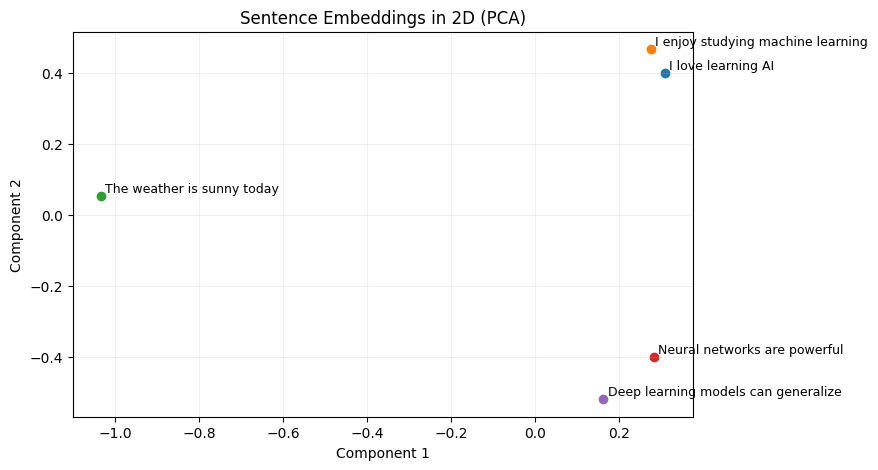

In [10]:
# Student Tip: Reduce embeddings to 2D with PCA and plot them.
# Label each point with sentence text.
# Use the plot to explain semantic clustering visually.

# Reduce embedding vectors to 2 dimensions for visualization.
pca = PCA(n_components=2)
points = pca.fit_transform(embeddings)

# Create figure canvas.
plt.figure(figsize=(8, 5))

# Plot each sentence point and annotate with text label.
for i, sentence in enumerate(sentences):
    x, y = points[i]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, sentence, fontsize=9)

# Add chart title/labels/grid for interpretability.
plt.title("Sentence Embeddings in 2D (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(alpha=0.2)

# Render the plot.
plt.show()

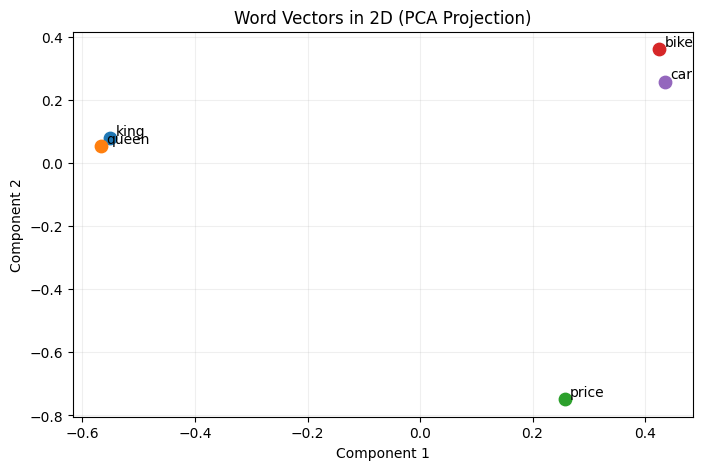

Cosine similarity matrix (higher means more semantically related):
[[1.    0.681 0.255 0.309 0.288]
 [0.681 1.    0.255 0.269 0.298]
 [0.255 0.255 1.    0.291 0.334]
 [0.309 0.269 0.291 1.    0.556]
 [0.288 0.298 0.334 0.556 1.   ]]

How to explain this plot to students:
- Words that appear closer in the 2D plot are usually more related in meaning.
- 'bike' and 'car' are expected to be relatively close (both are vehicles).
- 'king' and 'queen' are expected to be relatively close (both are royalty terms).
- 'price' may sit farther from vehicle/royalty clusters depending on model semantics.
- PCA is a 2D projection of higher-dimensional vectors, so it is intuition, not perfect truth.


In [11]:
# Student Tip: Build a small word-vector demo with words like king, queen, bike, car, price.
# Plot 2D PCA projection and print cosine similarity matrix.
# Explain which words appear closer and why.

# Word-level vector demo to build intuition about semantic neighborhoods.

# numpy: numerical utilities, matplotlib: visualization.
import numpy as np
import matplotlib.pyplot as plt

# PCA: dimension reduction, cosine_similarity: semantic closeness metric.
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# SentenceTransformer: quickly generate dense vectors for words/text.
from sentence_transformers import SentenceTransformer

# Small vocabulary sample for demonstration.
word_list = ["king", "queen", "price", "bike", "car"]

# Load embedding model and encode words into vectors.
word_embedder = SentenceTransformer("all-MiniLM-L6-v2")
word_vectors = word_embedder.encode(word_list)

# Project vectors to 2D for plotting.
word_points_2d = PCA(n_components=2).fit_transform(word_vectors)

# Create and populate scatter plot.
plt.figure(figsize=(8, 5))
for index, word in enumerate(word_list):
    x, y = word_points_2d[index]
    plt.scatter(x, y, s=80)
    plt.text(x + 0.01, y + 0.01, word, fontsize=10)

# Add labels and display chart.
plt.title("Word Vectors in 2D (PCA Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(alpha=0.2)
plt.show()

# Compute and print cosine similarity matrix.
sim_matrix = cosine_similarity(word_vectors)
print("Cosine similarity matrix (higher means more semantically related):")
print(np.round(sim_matrix, 3))

# Printed explanation lines to narrate during recording.
print("\nHow to explain this plot to students:")
print("- Words that appear closer in the 2D plot are usually more related in meaning.")
print("- 'bike' and 'car' are expected to be relatively close (both are vehicles).")
print("- 'king' and 'queen' are expected to be relatively close (both are royalty terms).")
print("- 'price' may sit farther from vehicle/royalty clusters depending on model semantics.")
print("- PCA is a 2D projection of higher-dimensional vectors, so it is intuition, not perfect truth.")

### Embedding Model Dimension Comparison (OpenAI + Local Models)
This demo uses your `.env` `OPENAI_API_KEY` for OpenAI embedding models and compares dimensions with local SentenceTransformer models.

In [12]:
# Student Tip: Compare embedding dimensions across OpenAI and local models.
# Load OPENAI_API_KEY from .env and handle missing key gracefully.
# Print model name and vector dimension for each model tested.
# os: environment variables, pathlib: path handling.
import os
from pathlib import Path

# dotenv: load API keys from .env file.
from dotenv import load_dotenv

# OpenAI client for embedding API calls.
from openai import OpenAI

# Local embedding model interface.
from sentence_transformers import SentenceTransformer

# Load .env from current working directory if available.
load_dotenv()
workspace_env = Path.cwd() / ".env"
if workspace_env.exists():
    load_dotenv(workspace_env, override=False)

# Example text used for all dimension checks.
sample_text = "Embeddings convert text into numeric vectors."

print("Embedding dimensions by model:\n")

# 1) OpenAI models (requires OPENAI_API_KEY in environment)
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    print("OPENAI_API_KEY not found in .env. Skipping OpenAI model calls.\n")
else:
    # Initialize API client.
    client = OpenAI(api_key=api_key)
    openai_models = ["text-embedding-3-small", "text-embedding-3-large"]

    # Query each model and print resulting embedding length.
    for model_name in openai_models:
        try:
            response = client.embeddings.create(
                model=model_name,
                input=sample_text
            )
            vec = response.data[0].embedding
            print(f"OpenAI  | {model_name:<24} | dimension = {len(vec)}")
        except Exception as exc:
            print(f"OpenAI  | {model_name:<24} | error: {exc}")

print()

# 2) Local sentence-transformer models
local_models = ["all-MiniLM-L6-v2", "all-mpnet-base-v2"]
for model_name in local_models:
    try:
        model = SentenceTransformer(model_name)
        vec = model.encode(sample_text)
        print(f"Local   | {model_name:<24} | dimension = {len(vec)}")
    except Exception as exc:
        print(f"Local   | {model_name:<24} | error: {exc}")

# Teaching takeaway line.
print("\nTeaching note: higher dimension is a trade-off between quality, speed, and cost.")

Embedding dimensions by model:

OpenAI  | text-embedding-3-small   | dimension = 1536
OpenAI  | text-embedding-3-large   | dimension = 3072

Local   | all-MiniLM-L6-v2         | dimension = 384
Local   | all-mpnet-base-v2        | dimension = 768

Teaching note: higher dimension is a trade-off between quality, speed, and cost.


## Real-World Embedding Model Selection Examples (for Engineers)

### Scenario 1: Lightweight Demo / Prototype
- **Use case:** Internal FAQ chatbot for a startup  
- **Recommended model:** `all-MiniLM-L6-v2` (**384 dimensions**)  
- **Why:** Fast, cost-effective, and strong enough for early-stage demos

---

### Scenario 2: Production Search / RAG System
- **Use case:** E-commerce product search (mid-range baseline)  
- **Recommended model:** `all-mpnet-base-v2` (**768 dimensions**)  
- **Why:** Better semantic coverage and retrieval quality for production workloads

---

### Scenario 3: High-Stakes Retrieval
- **Use case:** Legal document search (high precision required)  
- **Simulation idea:** Compare **384-dim vs 768-dim** similarity scores on ambiguous legal text  
- **Production note:** OpenAI embedding models can also be evaluated via API for higher-accuracy needs

## 4) Transformer Architecture
Core blocks:
- Input embeddings + positional encodings
- Multi-head self-attention
- Feed-forward network
- Residual connections + layer norm

A transformer stacks these blocks many times.

### Transformer Core Intuition (from Slides)
Sentence example: **"The animal didn't cross the street because it was tired."**
- Attention helps the model connect **"it" â†’ "animal"** using context.
- Key shift from older models: each token can attend to all other tokens in parallel.
- Why it matters: better long-context handling and faster training at scale.

## 5) Attention Mechanism (Coding Demo)

In [22]:
# Student Tip: Implement a simple scaled dot-product attention example.
# Create Q, K, V matrices, compute scores, softmax weights, and output vectors.
# Verify each attention row sums to 1.

def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

# Example tokens:
tokens = ["I", "love", "AI"]

# d_k = key/ query dimension:
d_k = 4

# Raamdom Q, K, V matrics for math demonstration:
Q = np.random.rand(3, d_k)
K = np.random.rand(3, d_k)
V = np.random.rand(3, d_k)

# Scaled dot-product attention scores:
scores = Q @ K.T/ np.sqrt(d_k)

# Normalize scores into attention weights:
weights = softmax(scores)

# Weighted combination of value vectors:
output = weights @ V

# Print intermediate & Final results
print("Attention score matrix:\n", np.round(scores, 3))
print("Attention weights (rows sum to 1):\n", np.round(weights, 3))
print("Output vectors:\n", np.round(output, 3))

Attention score matrix:
 [[0.595 0.594 0.11 ]
 [0.448 0.708 0.203]
 [0.485 0.751 0.168]]
Attention weights (rows sum to 1):
 [[0.382 0.382 0.236]
 [0.325 0.421 0.254]
 [0.33  0.43  0.24 ]]
Output vectors:
 [[0.274 0.544 0.553 0.49 ]
 [0.263 0.567 0.525 0.504]
 [0.267 0.56  0.519 0.51 ]]


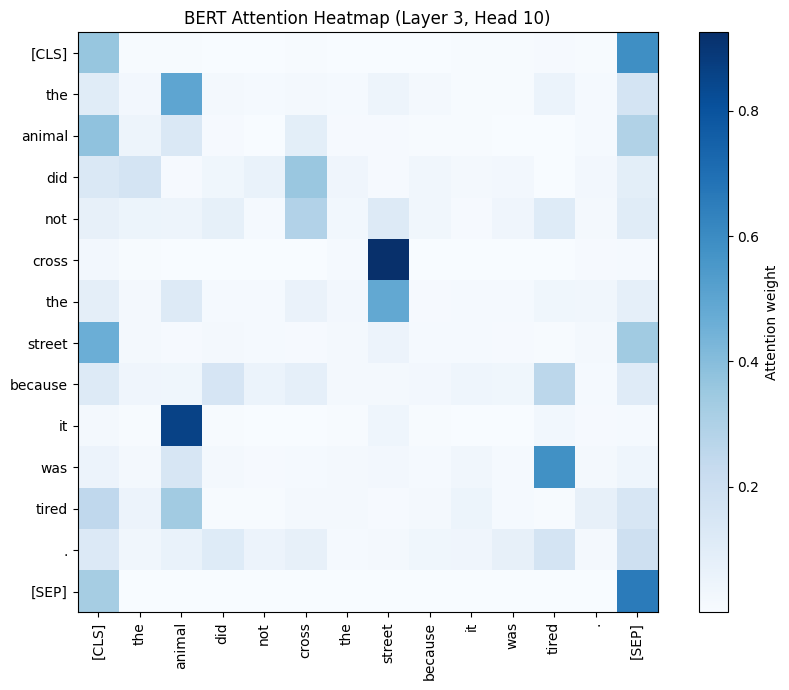

How to read this heatmap:
- Row token attends to column token.
- Darker color means stronger attention.

Selected head maximizes attention: it -> animal = 0.860

Top semantic tokens attended by 'it':
1. animal     weight=0.860  <-- likely reference
2. street     weight=0.041
3. tired      weight=0.029
4. the        weight=0.006
5. the        weight=0.005

Teaching note: different heads capture different patterns; we selected one that highlights 'it' -> 'animal'.


In [23]:
# Student Tip: Visualize real BERT attention on a sentence with coreference (it -> animal).
# Find a strong layer-head pair and render a heatmap.
# Print top attended tokens for the target token and interpret results.
# Real attention visualization focused on a coreference example.

# torch: tensor/model runtime, numpy: array ops, matplotlib: heatmap plotting.
import torch
import numpy as np
import matplotlib.pyplot as plt

# AutoTokenizer/AutoModel: load pretrained BERT with attention outputs.
from transformers import AutoTokenizer, AutoModel

# Sentence where 'it' should refer to 'animal'.
sentence = "The animal did not cross the street because it was tired."

# Load tokenizer and model with attentions enabled.
tokenizer_attn = AutoTokenizer.from_pretrained("bert-base-uncased")
model_attn = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True)

# Convert sentence to model inputs.
model_inputs = tokenizer_attn(sentence, return_tensors="pt")

# Run model inference without gradient tracking.
with torch.no_grad():
    model_outputs = model_attn(**model_inputs)

# Convert IDs back to readable token strings.
token_list = tokenizer_attn.convert_ids_to_tokens(model_inputs["input_ids"][0])

# attentions is a tuple: one tensor per layer.
attentions = model_outputs.attentions

# Ensure key tokens exist before searching best head.
if "it" not in token_list or "animal" not in token_list:
    print("Expected tokens not found exactly. Try another sentence.")
else:
    # Locate token positions.
    it_index = token_list.index("it")
    animal_index = token_list.index("animal")

    # Find layer/head where attention(it -> animal) is highest.
    best_layer, best_head, best_score = 0, 0, -1.0
    for layer_idx, layer_attn in enumerate(attentions):
        head_matrices = layer_attn[0].cpu().numpy()  # shape: [heads, seq_len, seq_len]
        for head_idx in range(head_matrices.shape[0]):
            score = float(head_matrices[head_idx, it_index, animal_index])
            if score > best_score:
                best_score = score
                best_layer, best_head = layer_idx, head_idx

    # Select the most illustrative attention matrix.
    selected_matrix = attentions[best_layer][0][best_head].cpu().numpy()

    # Plot heatmap.
    plt.figure(figsize=(9, 7))
    plt.imshow(selected_matrix, cmap="Blues")
    plt.colorbar(label="Attention weight")
    plt.title(f"BERT Attention Heatmap (Layer {best_layer}, Head {best_head})")
    plt.xticks(range(len(token_list)), token_list, rotation=90)
    plt.yticks(range(len(token_list)), token_list)
    plt.tight_layout()
    plt.show()

    # Explain reading strategy.
    print("How to read this heatmap:")
    print("- Row token attends to column token.")
    print("- Darker color means stronger attention.")
    print(f"\nSelected head maximizes attention: it -> animal = {best_score:.3f}")

    # Ignore non-semantic/special tokens when ranking attended words.
    ignore_tokens = {"[CLS]", "[SEP]", ".", ",", "!", "?", ";", ":"}
    candidate_indices = [
        idx for idx, tok in enumerate(token_list)
        if idx != it_index and tok not in ignore_tokens
    ]

    # Rank tokens attended by 'it'.
    it_attention = selected_matrix[it_index]
    ranked = sorted(candidate_indices, key=lambda idx: it_attention[idx], reverse=True)[:5]

    print("\nTop semantic tokens attended by 'it':")
    for rank, idx in enumerate(ranked, start=1):
        marker = "  <-- likely reference" if token_list[idx] == "animal" else ""
        print(f"{rank}. {token_list[idx]:<10} weight={it_attention[idx]:.3f}{marker}")

    print("\nTeaching note: different heads capture different patterns; we selected one that highlights 'it' -> 'animal'.")

## 6) Encoder vs Decoder vs Seq2Seq
- **Encoder-only** (e.g., BERT): best for understanding/classification
- **Decoder-only** (e.g., GPT): best for generation
- **Encoder-Decoder** (e.g., T5/BART): best for inputâ†’output transformations (translation/summarization)

### Quick Decision Rule + Real-World Mapping
**Decision rule (30-second memory trick):**
- If output is a **label** use **Encoder-only**
- If output is **open-ended continuation** use **Decoder-only**
- If output is **input transformed to output** use **Encoder-Decoder (Seq2Seq)**

**Real-world task mapping**
| Task | Input | Expected Output | Best Architecture | Why |
|---|---|---|---|---|
| Spam detection | Email text | `Spam` / `Not Spam` | Encoder-only | Pure understanding/classification |
| AI chat reply | User prompt | Free-form response | Decoder-only | Token-by-token generation |
| Summarize meeting notes | Long notes | Short summary | Encoder-Decoder | Transform long input into concise output |

In [1]:
# Student Tip: Compare encoder-only, decoder-only, and encoder-decoder behavior using pipelines.
# Run one classification example, one generation prompt, and one summarization example.
# Note how output format changes by architecture type.

# pipeline provides task-ready model wrappers.
from transformers import pipeline

# -----------------------------
# 1) Encoder-only: classification
# -----------------------------
print("1) Encoder-only demo (classification)")

# Load sentiment classification pipeline.
encoder_demo = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
 )

# Example input text for classification.
encoder_text = "I really enjoyed this AI class and the examples were very clear."

# Run model and print label + score.
encoder_result = encoder_demo(encoder_text)
print("Input:", encoder_text)
print("Output:", encoder_result)

d:\Mentoring\learwithsarvesh\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1) Encoder-only demo (classification)


Device set to use cpu


Input: I really enjoyed this AI class and the examples were very clear.
Output: [{'label': 'POSITIVE', 'score': 0.999772846698761}]


In [2]:
# -----------------------------
# 2) Decoder-only: generation
# -----------------------------
print("\n2) Decoder-only demo (generation)")

# Load generation pipeline.
decoder_demo = pipeline("text-generation", model="distilgpt2")

# Prompt to continue.
decoder_prompt = "AI in education can help students by"

# Generate continuation with sampling.
decoder_result = decoder_demo(
    decoder_prompt,
    max_new_tokens=30,
    do_sample=True,
    temperature=0.8,
    pad_token_id=50256
 )
print("Prompt:", decoder_prompt)
print("Output:", decoder_result[0]["generated_text"] )


2) Decoder-only demo (generation)


Device set to use cpu


Prompt: AI in education can help students by
Output: AI in education can help students by training them in how to communicate with others.


In [3]:
# pipeline provides task-ready model wrappers.
from transformers import pipeline

# --------------------------------------
# 3) Encoder-decoder: text transformation
# --------------------------------------
print("\n3) Encoder-Decoder demo (summarization)")

# FLAN-T5 can perform instruction-style text-to-text tasks.
seq2seq_demo = pipeline("text2text-generation", model="google/flan-t5-small")

# Longer input text for summary.
long_text = (
    "Transformers improved NLP by allowing parallel processing and better long-range context handling. "
    "Encoder-only models are strong for understanding tasks, decoder-only models excel at text generation, "
    "and encoder-decoder models are ideal for transformations like summarization and translation."
 )

# Ask model to summarize the text.
seq2seq_result = seq2seq_demo(
    "summarize: " + long_text,
    max_new_tokens=35
 )
print("Input text:", long_text)
print("Summary:", seq2seq_result[0]["generated_text"])

# Final recap line.
print("\nTeaching takeaway:")
print("- Encoder = understand")
print("- Decoder = generate")
print("- Encoder-Decoder = transform input into output")


3) Encoder-Decoder demo (summarization)


Device set to use cpu


Input text: Transformers improved NLP by allowing parallel processing and better long-range context handling. Encoder-only models are strong for understanding tasks, decoder-only models excel at text generation, and encoder-decoder models are ideal for transformations like summarization and translation.
Summary: Transformers improved NLP by allowing parallel processing and better long-range context handling. Encoder-only models are strong for understanding tasks, decoder-only

Teaching takeaway:
- Encoder = understand
- Decoder = generate
- Encoder-Decoder = transform input into output


## 7) BERT Explained (Coding Demo)

In [1]:
# Student Tip: Load bert-base-uncased tokenizer + model and run a forward pass.
# Print input shape, last hidden state shape, and CLS embedding shape.
# Use this to explain BERT output structure.
# Load BERT tokenizer and base encoder model.
from transformers import AutoTokenizer, AutoModel


bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_model = AutoModel.from_pretrained("bert-base-uncased")

# Example sentence.
sample = "BERT is an encoder-only transformer model."

# Convert text to tensors.
inputs = bert_tokenizer(sample, return_tensors="pt")

# Forward pass through BERT.
outputs = bert_model(**inputs)

# Print structural shapes for explanation.
print("Input IDs shape:", inputs["input_ids"].shape)
print("Last hidden state shape:", outputs.last_hidden_state.shape)
print("[CLS] embedding shape:", outputs.last_hidden_state[:, 0, :].shape)

d:\Mentoring\learwithsarvesh\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Input IDs shape: torch.Size([1, 14])
Last hidden state shape: torch.Size([1, 14, 768])
[CLS] embedding shape: torch.Size([1, 768])


In [2]:
# BERT sentence understanding demo via [CLS] similarity.

# torch for tensor operations; F for normalization utilities.
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel

# Load tokenizer and model.
bert_tok_sim = AutoTokenizer.from_pretrained("bert-base-uncased")
bert_sim_model = AutoModel.from_pretrained("bert-base-uncased")

# Example sentences (two related, one unrelated).
sim_sentences = [
    "I love learning AI.",
    "I enjoy studying machine learning.",
    "The weather is hot today."
]

# Tokenize as a padded batch.
encoded = bert_tok_sim(sim_sentences, return_tensors="pt", padding=True, truncation=True)

# Inference without gradients.
with torch.no_grad():
    outputs = bert_sim_model(**encoded)

# Extract [CLS] embedding per sentence.
cls_embeddings = outputs.last_hidden_state[:, 0, :]

# L2-normalize vectors before cosine-style dot product.
norm_embeddings = F.normalize(cls_embeddings, p=2, dim=1)

# Pairwise similarity matrix.
similarity_matrix = norm_embeddings @ norm_embeddings.T

# Print sentence index map.
print("Sentences:")
for i, s in enumerate(sim_sentences):
    print(f"{i}: {s}")

# Print similarity matrix.
print("\n[CLS]-based cosine similarity matrix:")
print(similarity_matrix.numpy().round(3))

# Interpretation line for recording.
print("\nInterpretation:")
print("- Sentences 0 and 1 should be closer than sentence 2.")
print("- This shows BERT captures semantic similarity for understanding tasks.")

Sentences:
0: I love learning AI.
1: I enjoy studying machine learning.
2: The weather is hot today.

[CLS]-based cosine similarity matrix:
[[1.    0.966 0.9  ]
 [0.966 1.    0.909]
 [0.9   0.909 1.   ]]

Interpretation:
- Sentences 0 and 1 should be closer than sentence 2.
- This shows BERT captures semantic similarity for understanding tasks.


In [3]:
# BERT masked language modeling demo: predict the missing token.
from transformers import pipeline

# Load fill-mask pipeline with BERT.
unmasker = pipeline("fill-mask", model="bert-base-uncased")

# Sentence with one masked slot.
masked_text = "The sky is [MASK]."

# Get top 5 candidate predictions.
predictions = unmasker(masked_text, top_k=5)

# Print results.
print("Input:", masked_text)
print("Top predictions:")
for pred in predictions:
    print(f"- {pred['token_str'].strip():<12} score={pred['score']:.4f}")

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Input: The sky is [MASK].
Top predictions:
- clear        score=0.2010
- blue         score=0.1899
- dark         score=0.1326
- gray         score=0.0625
- black        score=0.0546


#### Context sensitivity

In [4]:
# Context sensitivity demo: same [MASK], different surrounding context.
from transformers import pipeline

# Load fill-mask pipeline.
unmask = pipeline("fill-mask", model="bert-base-uncased")

# Two contexts for the same blank token.
case_1 = "The [MASK] approved the loan."
case_2 = "The fisherman sat on the [MASK] of the river."

# Predict top candidates for case 1.
print("Case 1:", case_1)
for pred in unmask(case_1, top_k=5):
    print(f"- {pred['token_str'].strip():<12} score={pred['score']:.4f}")

# Predict top candidates for case 2.
print("\nCase 2:", case_2)
for pred in unmask(case_2, top_k=5):
    print(f"- {pred['token_str'].strip():<12} score={pred['score']:.4f}")

# Teaching conclusion.
print("\nTeaching point:")
print("- BERT predictions shift with context, even when sentence structure is similar.")

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


Case 1: The [MASK] approved the loan.
- council      score=0.1026
- board        score=0.0877
- government   score=0.0805
- court        score=0.0633
- city         score=0.0386

Case 2: The fisherman sat on the [MASK] of the river.
- bank         score=0.7663
- edge         score=0.1351
- banks        score=0.0468
- side         score=0.0116
- shore        score=0.0097

Teaching point:
- BERT predictions shift with context, even when sentence structure is similar.


In [17]:
# Student Tip: Use CLS embeddings to compare semantic similarity between sentences.
# Normalize vectors, compute cosine similarity matrix, and print rounded output.
# Check that semantically close sentences have higher similarity.

In [18]:
# Student Tip: Run a masked language modeling demo with fill-mask.
# Use a sentence like 'The sky is [MASK].' and print top predictions.
# Explain how BERT predicts missing tokens from context.

In [19]:
# Student Tip: Show context sensitivity with two masked sentences using the same blank.
# Print top predictions for each sentence and compare them.
# Explain how surrounding context changes token prediction.

## 8) GPT Model Family

In [2]:
# GPT decoding settings demo: low vs high temperature.
from transformers import pipeline

# Load a lightweight GPT model for local generation.
gpt_demo = pipeline("text-generation", model="distilgpt2")

# Shared prompt for fair comparison.
prompt = "In AI education, a good mentor should"

# Low temperature: more focused/predictable generation.
low_temp = gpt_demo(
    prompt,
    max_new_tokens=35,
    do_sample=True,
    temperature=0.2,
    top_p=0.9,
    num_return_sequences=1,
    pad_token_id=50256
 )[0]["generated_text"]

# High temperature: more diverse/creative generation.
high_temp = gpt_demo(
    prompt,
    max_new_tokens=35,
    do_sample=True,
    temperature=1.0,
    top_p=0.95,
    num_return_sequences=1,
    pad_token_id=50256
 )[0]["generated_text"]

'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: cfd40986-6e07-4c53-b3b4-5873fa334046)')' thrown while requesting HEAD https://huggingface.co/distilgpt2/resolve/main/config.json
Retrying in 1s [Retry 1/5].
'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: 1831a424-7776-41a9-a346-c45563c762e7)')' thrown while requesting HEAD https://huggingface.co/distilgpt2/resolve/main/generation_config.json
Retrying in 1s [Retry 1/5].
Device set to use cpu


In [3]:
# Print both outputs for comparison.
print("Prompt:", prompt)
print("\nLow temperature (0.2) output:\n", low_temp)
print("\nHigh temperature (1.0) output:\n", high_temp)

# Interpretation lines for narration.
print("\nInterpretation:")
print("- Low temperature is usually more focused and predictable.")
print("- High temperature is usually more diverse/creative, sometimes less stable.")

Prompt: In AI education, a good mentor should

Low temperature (0.2) output:
 In AI education, a good mentor should be able to help you develop a better understanding of the world.























High temperature (1.0) output:
 In AI education, a good mentor should look to this as well as to help ensure that there are no shortcuts to training them and that these are not the right ones.



For more information about AI

Interpretation:
- Low temperature is usually more focused and predictable.
- High temperature is usually more diverse/creative, sometimes less stable.


In [21]:
# Student Tip: Run an optional lightweight GPT generation demo.
# Use distilgpt2 with max_new_tokens, temperature, and top_p settings.
# Print generated text and summarize one quality observation.

In [4]:
# Optional local generation demo with simple decoding settings.
from transformers import pipeline

# Load distilgpt2 generator.
generator = pipeline("text-generation", model="distilgpt2")

# Prompt for continuation.
prompt = "In 2026, AI engineers should focus on"

# Generate text continuation.
result = generator(
    prompt,
    max_new_tokens=35,
    do_sample=True,
    temperature=0.8,
    top_p=0.95,
    pad_token_id=50256
 )

# Print generated output.
print(result[0]["generated_text"])


Device set to use cpu


In 2026, AI engineers should focus on the fundamental problems of the future.






























## 9) How LLMs Reason
LLMs do not reason like humans; they perform pattern-based token prediction with internal representations that can approximate reasoning behaviors.

Practical takeaway:
- Better prompts improve output structure
- Tools + retrieval improve factual quality
- Verification steps reduce hallucinations

## 10) Limitations of LLMs
- Hallucinations (confident but wrong answers)
- Knowledge cutoff / stale information
- Prompt sensitivity
- Bias and safety concerns
- Context window limits

Mitigations: RAG, evaluation loops, grounding with tools, human-in-the-loop.

## Session Wrap-Up
By the end of this session, learners can:
- Explain core LLM concepts and architecture differences
- Run tokenization and embedding demos
- Interpret basic attention math output
- Describe when to use BERT vs GPT-style models